# This is the training and test program for 3D U-net for MP2RAGE MRI images
Make sure to update and verify all of the file and folder directories


##Import packages

In [ ]:
import torch
import torch.nn as nn
import scipy.ndimage as ndi
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import os
import nibabel as nib
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import closing, remove_small_objects, disk, ball
from scipy.ndimage import binary_fill_holes, label
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast
import pydicom
from pydicom import dcmread

##Creating foreground mask using percentage threshold

In [ ]:
#Generate a 3D binary mask using a percentage threshold and morphological operations.
def create_foreground_mask(volume, threshold_percentage=0.05):
    # Threshold to remove air/background
    mask = volume > (threshold_percentage * np.max(volume))

    # Apply morphological operations based on image dimensions
    if volume.ndim == 2:
        mask = closing(mask, disk(radius=3))
    elif volume.ndim == 3:
        mask = closing(mask, ball(radius=3))
    else:
        raise ValueError("Input volume must be 2D or 3D.")

    mask = binary_fill_holes(mask)
    mask = remove_small_objects(mask, min_size=100)

    return mask.astype(np.uint8)

#Save the mask as a .nii.gz file with the same affine and header as the input image.
def save_mask(mask, reference_nii, output_path):
    mask_nifti = nib.Nifti1Image(mask.astype(np.uint8), affine=reference_nii.affine, header=reference_nii.header)
    nib.save(mask_nifti, output_path)

def create_mask(img_data):
    # 1) Threshold to remove air/background
    mask0 = img_data > (0.05 * img_data.max())

    if img_data.ndim == 2:
        mask1 = closing(mask0, disk(radius=3))
    elif img_data.ndim == 3:
        mask1 = closing(mask0, ball(radius=3))
    else:
        raise ValueError("Input volume must be 2D or 3D.")


    # 2) Keep only the largest connected component (the head)
    labels, n = ndi.label(mask1)
    sizes = ndi.sum(mask1, labels, range(1, n+1))
    largest = np.argmax(sizes) + 1
    whole_head_mask = (labels == largest).astype(np.uint8)
    return whole_head_mask

In [ ]:
test_input_dir = "/content/drive/My Drive/lemon_data/mp2rage_ex3750/inv2/i29484956.MRDC.1"

test_img = dcmread(test_input_dir)
test_data = test_img.pixel_array

print(type(test_data))
print(test_data.shape)

test_mask = create_foreground_mask(test_data)

<class 'numpy.ndarray'>
(512, 512)


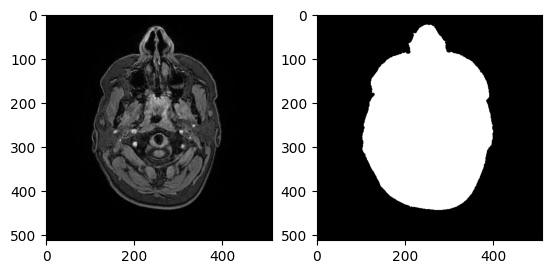

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(test_data, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(test_mask, cmap="gray")